

**LEVEL 1 — TASK 4**

**SENTIMENT ANALYSIS**

**Project Overview**

This project focuses on performing sentiment analysis on a dataset containing text-based social media data. The objective is to preprocess textual data, extract meaningful features using TF-IDF, and develop machine-learning models to classify text into broad sentiment categories.

**Objective**

The main objectives of this project are:

- To inspect and understand the given sentiment dataset.
- To clean and preprocess the text data.
- To analyze the distribution of sentiment categories.
- To transform text into numerical features using TF-IDF.
- To train and evaluate two machine-learning classification models.
- To compare model performance using appropriate evaluation metrics.
- To perform error analysis on the model predictions.

### Dataset Overview

The dataset contains **732 records and 15 columns**. Important columns include:

- `Text` — the original text data.
- `Sentiment` — the original detailed sentiment/emotion label.
- `Timestamp` — timestamp associated with the text.
- `Platform` — platform information.
- `Hashtags` — hashtags associated with the text.
- `Retweets` — number of retweets.
- `Likes` — number of likes.
- `Country` — country information.

The original sentiment column contained a large number of detailed emotion labels. After removing unnecessary whitespace, **191 distinct sentiment labels** were identified.

For practical classification, the detailed sentiment labels were grouped into three broad categories:

- **Positive**
- **Neutral**
- **Negative**

The original detailed sentiment labels were preserved separately in `Sentiment_Original`.

### Tools and Technologies

- Python
- Google Colab
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- TF-IDF
- Logistic Regression
- Multinomial Naive Bayes

### Project Workflow

**Data Loading → Data Inspection → Sentiment Analysis → Data Cleaning → Text Preprocessing → Train/Test Split → TF-IDF → Model Training → Model Evaluation → Model Comparison → Error Analysis → Conclusion**

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving 3) Sentiment dataset.csv to 3) Sentiment dataset.csv


In [ ]:
import pandas as pd

filename = next(iter(uploaded))

df = pd.read_csv(filename)

print("Dataset loaded successfully!")
print("File name:", filename)
print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully!
File name: 3) Sentiment dataset.csv
Dataset shape: (732, 15)


,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [ ]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape:
(732, 15)

Column Names:
['Unnamed: 0.1', 'Unnamed: 0', 'Text', 'Sentiment', 'Timestamp', 'User', 'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day', 'Hour']

Data Types:
Unnamed: 0.1      int64
Unnamed: 0        int64
Text             object
Sentiment        object
Timestamp        object
User             object
Platform         object
Hashtags         object
Retweets        float64
Likes           float64
Country          object
Year              int64
Month             int64
Day               int64
Hour              int64
dtype: object

Missing Values:
Unnamed: 0.1    0
Unnamed: 0      0
Text            0
Sentiment       0
Timestamp       0
User            0
Platform        0
Hashtags        0
Retweets        0
Likes           0
Country         0
Year            0
Month           0
Day             0
Hour            0
dtype: int64


In [ ]:
print("Sentiment Categories:")
print(df["Sentiment"].unique())

print("\nSentiment Counts:")
print(df["Sentiment"].value_counts())

Sentiment Categories:
[' Positive  ' ' Negative  ' ' Neutral   ' ' Anger        '
 ' Fear         ' ' Sadness      ' ' Disgust      ' ' Happiness    '
 ' Joy          ' ' Love         ' ' Amusement    ' ' Enjoyment    '
 ' Admiration   ' ' Affection    ' ' Awe          ' ' Disappointed '
 ' Surprise     ' ' Acceptance   ' ' Adoration    ' ' Anticipation '
 ' Bitter       ' ' Calmness     ' ' Confusion    ' ' Excitement   '
 ' Kind         ' ' Pride        ' ' Shame        ' ' Confusion '
 ' Excitement ' ' Shame ' ' Elation       ' ' Euphoria      '
 ' Contentment   ' ' Serenity      ' ' Gratitude     ' ' Hope          '
 ' Empowerment   ' ' Compassion    ' ' Tenderness    ' ' Arousal       '
 ' Enthusiasm    ' ' Fulfillment  ' ' Reverence     ' ' Compassion'
 ' Fulfillment   ' ' Reverence ' ' Elation   ' ' Despair         '
 ' Grief           ' ' Loneliness      ' ' Jealousy        '
 ' Resentment      ' ' Frustration     ' ' Boredom         '
 ' Anxiety         ' ' Intimidation    ' '

In [ ]:
df["Text"] = df["Text"].astype(str).str.strip()
df["Sentiment"] = df["Sentiment"].astype(str).str.strip()

print("Unique sentiments after removing extra spaces:")
print(df["Sentiment"].nunique())

print("\nMost common sentiments:")
print(df["Sentiment"].value_counts().head(20))

Unique sentiments after removing extra spaces:
191

Most common sentiments:
Sentiment
Positive       45
Joy            44
Excitement     37
Contentment    19
Neutral        18
Gratitude      18
Curiosity      16
Serenity       15
Happy          14
Despair        11
Nostalgia      11
Hopeful         9
Loneliness      9
Awe             9
Grief           9
Sad             9
Embarrassed     8
Confusion       8
Acceptance      8
Euphoria        7
Name: count, dtype: int64


In [ ]:
df["Sentiment_Original"] = df["Sentiment"]

positive_labels = {
    "Positive", "Joy", "Excitement", "Contentment", "Gratitude",
    "Serenity", "Happy", "Hopeful", "Awe", "Acceptance", "Euphoria",
    "Love", "Happiness", "Amusement", "Enjoyment", "Admiration",
    "Affection", "Optimism", "Pride", "Proud", "Calmness",
    "Satisfaction", "Relief", "Inspiration", "Motivation", "Success",
    "Celebration", "Friendship", "Kindness", "Appreciation",
    "Accomplishment", "Empowerment", "Enthusiasm", "Thrill",
    "Overjoyed", "Confidence", "Confident", "Blessed", "Playful",
    "Harmony", "Wonder", "Marvel", "Amazement", "Romance",
    "Tranquility", "Radiance", "Fulfillment", "Compassion",
    "Tenderness", "Serenity"
}

negative_labels = {
    "Negative", "Anger", "Fear", "Sadness", "Disgust", "Despair",
    "Loneliness", "Grief", "Sad", "Embarrassed", "Disappointed",
    "Disappointment", "Bitter", "Bitterness", "Frustration",
    "Frustrated", "Anxiety", "Fearful", "Jealousy", "Jealous",
    "Envy", "Envious", "Resentment", "Regret", "Sorrow",
    "Heartbreak", "Heartache", "Betrayal", "Devastated",
    "Helplessness", "Isolation", "Desperation", "Desolation",
    "Loss", "Hate", "Suffering", "Melancholy", "Numbness",
    "Overwhelmed", "Exhaustion", "Darkness", "Solitude"
}

def classify_sentiment(label):
    if label in positive_labels:
        return "Positive"
    elif label in negative_labels:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment_Broad"] = df["Sentiment_Original"].apply(classify_sentiment)

print("Broad sentiment distribution:")
print(df["Sentiment_Broad"].value_counts())

print("\nBroad sentiment percentages:")
print(df["Sentiment_Broad"].value_counts(normalize=True).mul(100).round(2))

Broad sentiment distribution:
Sentiment_Broad
Positive    332
Neutral     240
Negative    160
Name: count, dtype: int64

Broad sentiment percentages:
Sentiment_Broad
Positive    45.36
Neutral     32.79
Negative    21.86
Name: proportion, dtype: float64


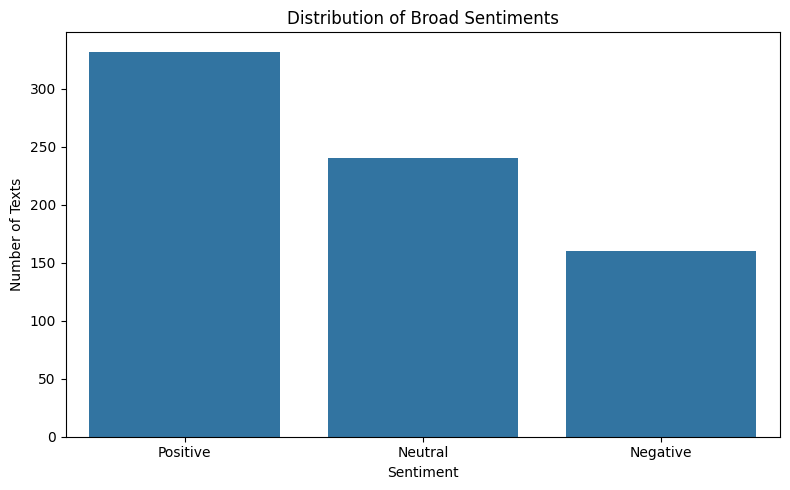

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Sentiment_Broad",
    order=["Positive", "Neutral", "Negative"]
)

plt.title("Distribution of Broad Sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Number of Texts")
plt.tight_layout()
plt.show()

In [ ]:
import re

def clean_text(text):
    text = str(text).lower()

    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    text = re.sub(r"@\w+", "", text)

    text = re.sub(r"#", "", text)

    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    text = re.sub(r"\s+", " ", text).strip()

    return text

df["Cleaned_Text"] = df["Text"].apply(clean_text)

print("Text preprocessing completed!")

display(df[["Text", "Cleaned_Text", "Sentiment_Broad"]].head(10))

Text preprocessing completed!


,Text,Cleaned_Text,Sentiment_Broad
0,Enjoying a beautiful day at the park!,enjoying a beautiful day at the park,Positive
1,Traffic was terrible this morning.,traffic was terrible this morning,Negative
2,Just finished an amazing workout! 💪,just finished an amazing workout,Positive
3,Excited about the upcoming weekend getaway!,excited about the upcoming weekend getaway,Positive
4,Trying out a new recipe for dinner tonight.,trying out a new recipe for dinner tonight,Neutral
5,Feeling grateful for the little things in life.,feeling grateful for the little things in life,Positive
6,Rainy days call for cozy blankets and hot cocoa.,rainy days call for cozy blankets and hot cocoa,Positive
7,The new movie release is a must-watch!,the new movie release is a must watch,Positive
8,Political discussions heating up on the timeline.,political discussions heating up on the timeline,Negative
9,Missing summer vibes and beach days.,missing summer vibes and beach days,Neutral


In [ ]:
from sklearn.model_selection import train_test_split

X = df["Cleaned_Text"]
y = df["Sentiment_Broad"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining sentiment distribution:")
print(y_train.value_counts())

print("\nTesting sentiment distribution:")
print(y_test.value_counts())

Training samples: 585
Testing samples: 147

Training sentiment distribution:
Sentiment_Broad
Positive    265
Neutral     192
Negative    128
Name: count, dtype: int64

Testing sentiment distribution:
Sentiment_Broad
Positive    67
Neutral     48
Negative    32
Name: count, dtype: int64


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF conversion completed!")

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

TF-IDF conversion completed!
Training TF-IDF shape: (585, 5000)
Testing TF-IDF shape: (147, 5000)


In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

print("Logistic Regression training completed!")

Logistic Regression training completed!


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", round(lr_accuracy, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.6395

Classification Report:
              precision    recall  f1-score   support

    Negative       0.93      0.41      0.57        32
     Neutral       0.72      0.38      0.49        48
    Positive       0.58      0.94      0.72        67

    accuracy                           0.64       147
   macro avg       0.74      0.57      0.59       147
weighted avg       0.70      0.64      0.61       147


Confusion Matrix:
[[13  3 16]
 [ 1 18 29]
 [ 0  4 63]]


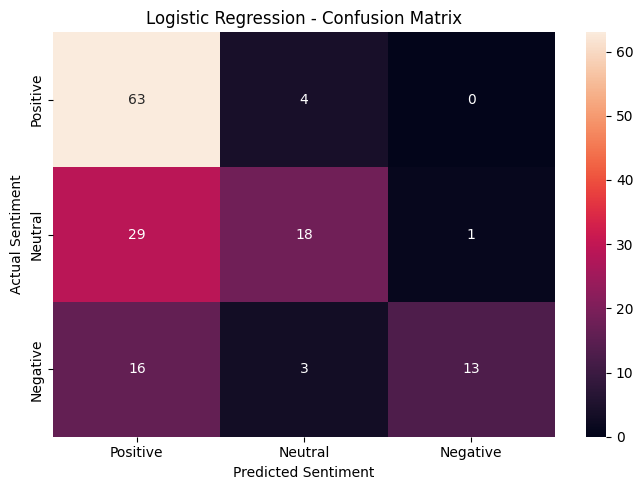

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cm_lr = confusion_matrix(
    y_test,
    y_pred_lr,
    labels=["Positive", "Neutral", "Negative"]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    xticklabels=["Positive", "Neutral", "Negative"],
    yticklabels=["Positive", "Neutral", "Negative"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

print("Multinomial Naive Bayes training completed!")

Multinomial Naive Bayes training completed!


In [ ]:
nb_accuracy = accuracy_score(y_test, y_pred_nb)

print("Multinomial Naive Bayes Accuracy:", round(nb_accuracy, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

Multinomial Naive Bayes Accuracy: 0.6259

Classification Report:
              precision    recall  f1-score   support

    Negative       0.92      0.38      0.53        32
     Neutral       0.71      0.31      0.43        48
    Positive       0.58      0.97      0.72        67

    accuracy                           0.63       147
   macro avg       0.74      0.55      0.56       147
weighted avg       0.70      0.63      0.59       147


Confusion Matrix:
[[12  4 16]
 [ 1 15 32]
 [ 0  2 65]]


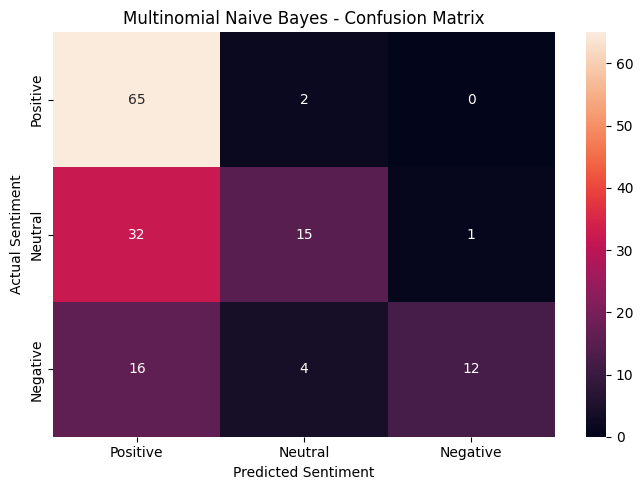

In [ ]:
cm_nb = confusion_matrix(
    y_test,
    y_pred_nb,
    labels=["Positive", "Neutral", "Negative"]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    xticklabels=["Positive", "Neutral", "Negative"],
    yticklabels=["Positive", "Neutral", "Negative"]
)

plt.title("Multinomial Naive Bayes - Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.tight_layout()
plt.show()

In [ ]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Multinomial Naive Bayes"
    ],
    "Accuracy": [
        lr_accuracy,
        nb_accuracy
    ]
})

model_results["Accuracy"] = model_results["Accuracy"].round(4)

print(model_results)

                     Model  Accuracy
0      Logistic Regression    0.6395
1  Multinomial Naive Bayes    0.6259


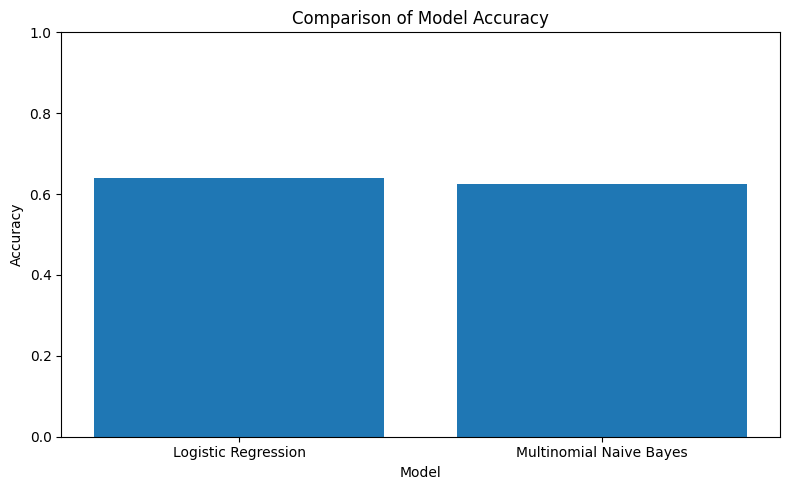

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    model_results["Model"],
    model_results["Accuracy"]
)

plt.title("Comparison of Model Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Multinomial Naive Bayes"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_nb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr, average="weighted"),
        precision_score(y_test, y_pred_nb, average="weighted")
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr, average="weighted"),
        recall_score(y_test, y_pred_nb, average="weighted")
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr, average="weighted"),
        f1_score(y_test, y_pred_nb, average="weighted")
    ]
})

comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.6395,0.7031,0.6395,0.6122
1,Multinomial Naive Bayes,0.6259,0.6964,0.6259,0.5872


In [ ]:
error_analysis = pd.DataFrame({
    "Text": X_test.values,
    "Actual": y_test.values,
    "Predicted": y_pred_lr
})

errors = error_analysis[
    error_analysis["Actual"] != error_analysis["Predicted"]
]

print("Number of incorrect predictions:", len(errors))

display(errors.head(20))

Number of incorrect predictions: 53


,Text,Actual,Predicted
0,swinging to the rhythms of a frank sinatra tri...,Neutral,Positive
12,in the midst of a soccer match an unexpected o...,Negative,Positive
15,an amusing incident brightened up my day,Positive,Neutral
19,overflowing adoration for a cute rescue puppy,Neutral,Positive
20,feeling a sense of emptiness after a close fri...,Negative,Positive
21,melancholy as a companion painting the canvas ...,Negative,Positive
22,intimidation by the unknown future ahead,Neutral,Positive
24,as the waves crash against the shore the surfe...,Neutral,Positive
25,exploring a new part time job opportunity for ...,Neutral,Positive
27,organizing a community cleanup event for a cle...,Neutral,Positive


In [ ]:
error_pairs = (
    errors.groupby(["Actual", "Predicted"])
    .size()
    .reset_index(name="Count")
    .sort_values("Count", ascending=False)
)

display(error_pairs)

,Actual,Predicted,Count
3,Neutral,Positive,29
1,Negative,Positive,16
4,Positive,Neutral,4
0,Negative,Neutral,3
2,Neutral,Negative,1


In [ ]:
output_file = "sentiment_analysis_processed.csv"

df.to_csv(output_file, index=False)

print("Processed dataset saved as:", output_file)

Processed dataset saved as: sentiment_analysis_processed.csv


In [ ]:
print("Final Model Comparison")
display(comparison.round(4))

Final Model Comparison


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.6395,0.7031,0.6395,0.6122
1,Multinomial Naive Bayes,0.6259,0.6964,0.6259,0.5872


In [ ]:
print("Total test samples:", len(y_test))
print("Incorrect predictions:", len(errors))
print("Correct predictions:", len(y_test) - len(errors))

print("\nMost common error patterns:")
display(error_pairs)

Total test samples: 147
Incorrect predictions: 53
Correct predictions: 94

Most common error patterns:


,Actual,Predicted,Count
3,Neutral,Positive,29
1,Negative,Positive,16
4,Positive,Neutral,4
0,Negative,Neutral,3
2,Neutral,Negative,1
